In [345]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load NAV data
nav = pd.read_csv("../data/processed/02_nav_history.csv")

print(nav.head())
print("\nShape:", nav.shape)

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692

Shape: (46000, 3)


In [346]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort values
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily returns
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

print(nav.head(10))
print("\nColumns:", nav.columns)

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639
5756     100016 2022-01-11  513.5542      0.005562
5757     100016 2022-01-12  512.3195     -0.002404
5758     100016 2022-01-13  510.2445     -0.004050
5759     100016 2022-01-14  514.3636      0.008073

Columns: Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='str')


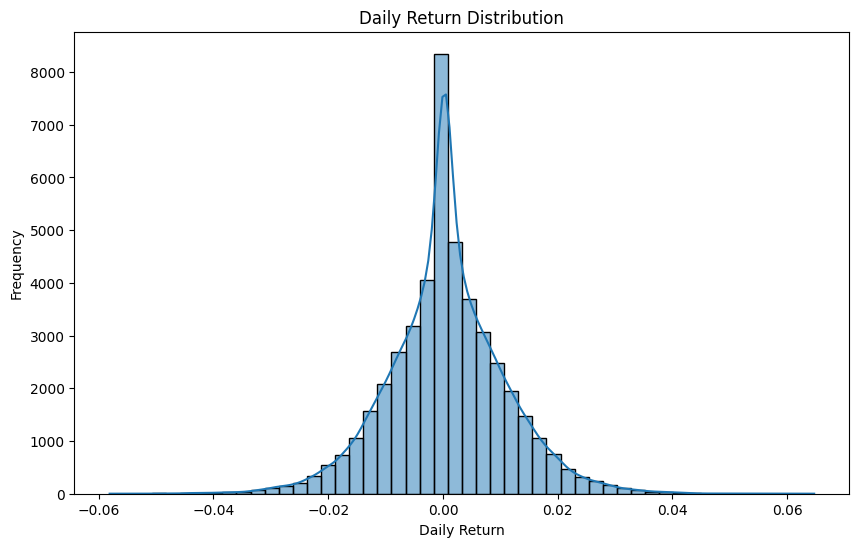

In [347]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [348]:
# Load scheme performance data
perf = pd.read_csv("../data/processed/07_scheme_performance.csv")

print(perf.head())
print("\nShape:", perf.shape)
print("\nColumns:", perf.columns)

   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   
3  Small Cap   Direct           20.59           23.14           21.82   
4       Gilt  Regular            5.34            6.07            5.43   

   benchmark_3yr_pct  alpha  beta  sharpe_ratio  sortino_ratio  \
0              11.49

In [349]:
# 3-Year CAGR

cagr_3yr = perf[["amfi_code", "scheme_name", "return_3yr_pct"]].copy()

cagr_3yr["CAGR_3yr"] = (
    (1 + cagr_3yr["return_3yr_pct"] / 100) ** (1/3) - 1
)

print(cagr_3yr.head())

   amfi_code                                   scheme_name  return_3yr_pct  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth           12.36   
1     119552      SBI Bluechip Fund - Direct Plan - Growth           11.30   
2     119598    SBI Small Cap Fund - Regular Plan - Growth           23.39   
3     119599     SBI Small Cap Fund - Direct Plan - Growth           23.14   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth            6.07   

   CAGR_3yr  
0  0.039610  
1  0.036331  
2  0.072572  
3  0.071848  
4  0.019837  


In [350]:
# 5-Year CAGR

cagr_5yr = perf[["amfi_code", "scheme_name", "return_5yr_pct"]].copy()

cagr_5yr["CAGR_5yr"] = (
    (1 + cagr_5yr["return_5yr_pct"] / 100) ** (1/5) - 1
)

print(cagr_5yr.head())

   amfi_code                                   scheme_name  return_5yr_pct  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth           14.45   
1     119552      SBI Bluechip Fund - Direct Plan - Growth           14.23   
2     119598    SBI Small Cap Fund - Regular Plan - Growth           20.67   
3     119599     SBI Small Cap Fund - Direct Plan - Growth           21.82   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth            5.43   

   CAGR_5yr  
0  0.027361  
1  0.026966  
2  0.038293  
3  0.040264  
4  0.010632  


In [351]:
cagr_table = perf[
    [
        "amfi_code",
        "scheme_name",
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct"
    ]
].copy()

cagr_table["CAGR_1yr"] = cagr_table["return_1yr_pct"] / 100
cagr_table["CAGR_3yr"] = (
    (1 + cagr_table["return_3yr_pct"] / 100) ** (1/3) - 1
)
cagr_table["CAGR_5yr"] = (
    (1 + cagr_table["return_5yr_pct"] / 100) ** (1/5) - 1
)

print(cagr_table.head())

   amfi_code                                   scheme_name  return_1yr_pct  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth           12.42   
1     119552      SBI Bluechip Fund - Direct Plan - Growth           15.25   
2     119598    SBI Small Cap Fund - Regular Plan - Growth           24.56   
3     119599     SBI Small Cap Fund - Direct Plan - Growth           20.59   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth            5.34   

   return_3yr_pct  return_5yr_pct  CAGR_1yr  CAGR_3yr  CAGR_5yr  
0           12.36           14.45    0.1242  0.039610  0.027361  
1           11.30           14.23    0.1525  0.036331  0.026966  
2           23.39           20.67    0.2456  0.072572  0.038293  
3           23.14           21.82    0.2059  0.071848  0.040264  
4            6.07            5.43    0.0534  0.019837  0.010632  


In [352]:
# Sharpe Ratio Ranking

sharpe_table = perf[
    ["amfi_code", "scheme_name", "sharpe_ratio"]
].copy()

sharpe_table = sharpe_table.sort_values(
    by="sharpe_ratio",
    ascending=False
)

sharpe_table["Rank"] = range(1, len(sharpe_table) + 1)

print(sharpe_table.head(10))

    amfi_code                                        scheme_name  \
14     120507           ICICI Pru Liquid Fund - Regular - Growth   
23     120844               Kotak Liquid Fund - Regular - Growth   
30     101208                ABSL Liquid Fund - Regular - Growth   
9      100025       HDFC Short Term Debt Fund - Regular - Growth   
4      119120       SBI Magnum Gilt Fund - Regular Plan - Growth   
19     118636  Nippon India Gilt Securities Fund - Regular - ...   
34     148567      Mirae Asset Large Cap Fund - Regular - Growth   
5      100016          HDFC Top 100 Fund - Regular Plan - Growth   
11     120504          ICICI Pru Bluechip Fund - Direct - Growth   
15     118632     Nippon India Large Cap Fund - Regular - Growth   

    sharpe_ratio  Rank  
14          7.68     1  
23          6.18     2  
30          5.14     3  
9           1.84     4  
4           1.52     5  
19          1.33     6  
34          1.06     7  
5           1.06     8  
11          1.03     9  
1

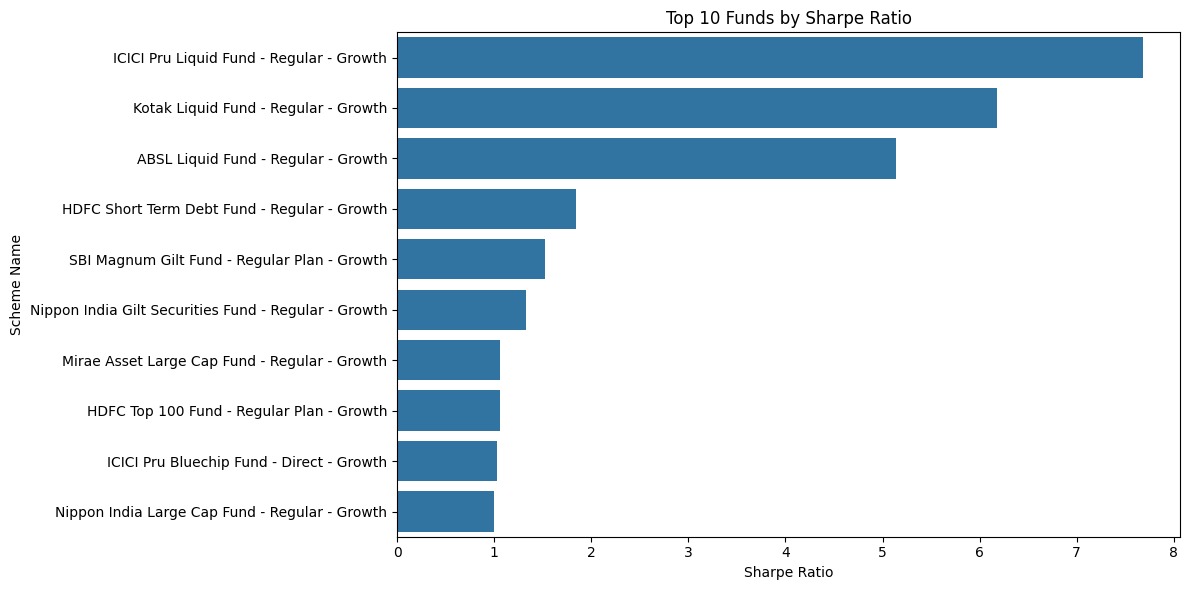

In [353]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sharpe_table.head(10),
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Scheme Name")

plt.tight_layout()
plt.show()

In [354]:
# Sortino Ratio Ranking

sortino_table = perf[
    ["amfi_code", "scheme_name", "sortino_ratio"]
].copy()

sortino_table = sortino_table.sort_values(
    by="sortino_ratio",
    ascending=False
)

sortino_table["Rank"] = range(1, len(sortino_table) + 1)

print(sortino_table.head(10))

    amfi_code                                        scheme_name  \
14     120507           ICICI Pru Liquid Fund - Regular - Growth   
23     120844               Kotak Liquid Fund - Regular - Growth   
30     101208                ABSL Liquid Fund - Regular - Growth   
9      100025       HDFC Short Term Debt Fund - Regular - Growth   
19     118636  Nippon India Gilt Securities Fund - Regular - ...   
4      119120       SBI Magnum Gilt Fund - Regular Plan - Growth   
5      100016          HDFC Top 100 Fund - Regular Plan - Growth   
15     118632     Nippon India Large Cap Fund - Regular - Growth   
3      119599          SBI Small Cap Fund - Direct Plan - Growth   
34     148567      Mirae Asset Large Cap Fund - Regular - Growth   

    sortino_ratio  Rank  
14          10.37     1  
23           9.70     2  
30           8.76     3  
9            2.79     4  
19           2.38     5  
4            2.11     6  
5            1.70     7  
15           1.68     8  
3            1.67

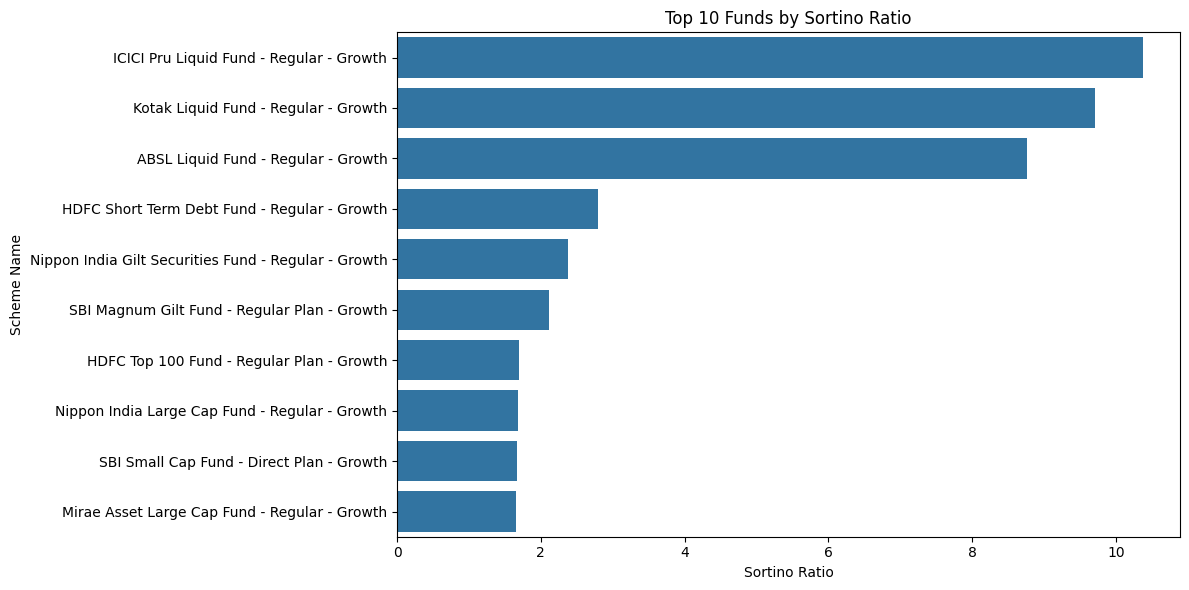

In [355]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sortino_table.head(10),
    x="sortino_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sortino Ratio")
plt.xlabel("Sortino Ratio")
plt.ylabel("Scheme Name")

plt.tight_layout()
plt.show()

In [356]:
benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

print(benchmark.head())
print("\nColumns:", benchmark.columns)
print("\nShape:", benchmark.shape)

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15

Columns: Index(['date', 'index_name', 'close_value'], dtype='str')

Shape: (8050, 3)


In [357]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

# NIFTY50 data
nifty = benchmark[benchmark["index_name"] == "NIFTY50"].copy()

# Daily returns
nifty["benchmark_return"] = nifty["close_value"].pct_change()

print(nifty.head())

        date index_name  close_value  benchmark_return
0 2022-01-03    NIFTY50     17492.79               NaN
1 2022-01-04    NIFTY50     17689.64          0.011253
2 2022-01-05    NIFTY50     17835.05          0.008220
3 2022-01-06    NIFTY50     17878.51          0.002437
4 2022-01-07    NIFTY50     17759.15         -0.006676


In [358]:
merged = nav.merge(
    nifty[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

print(merged.head())
print("\nShape:", merged.shape)

   amfi_code       date       nav  daily_return  benchmark_return
0     100016 2022-01-03  520.4608           NaN               NaN
1     100016 2022-01-04  515.0971     -0.010306          0.011253
2     100016 2022-01-05  521.7239      0.012865          0.008220
3     100016 2022-01-06  515.7880     -0.011377          0.002437
4     100016 2022-01-07  515.1639     -0.001210         -0.006676

Shape: (46000, 5)


In [359]:
from scipy.stats import linregress

results = []

for code in merged["amfi_code"].unique():

    df = merged[merged["amfi_code"] == code].dropna()

    if len(df) > 30:

        slope, intercept, r, p, stderr = linregress(
            df["benchmark_return"],
            df["daily_return"]
        )

        results.append({
            "amfi_code": code,
            "alpha": intercept * 252,
            "beta": slope
        })

alpha_beta = pd.DataFrame(results)

print(alpha_beta.head())
print("\nShape:", alpha_beta.shape)

   amfi_code     alpha      beta
0     100016  0.036221 -0.025909
1     100025  0.043189 -0.016176
2     100033  0.272343 -0.011200
3     101206  0.213945  0.033814
4     101207  0.108205 -0.059856

Shape: (40, 3)


In [360]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully!")

alpha_beta.csv saved successfully!


In [361]:
# Maximum Drawdown Calculation

drawdown_results = []

for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == code].copy()

    # Running maximum NAV
    df["running_max"] = df["nav"].cummax()

    # Drawdown
    df["drawdown"] = (
        (df["nav"] - df["running_max"])
        / df["running_max"]
    )

    max_dd = df["drawdown"].min()

    drawdown_results.append({
        "amfi_code": code,
        "max_drawdown": max_dd
    })

drawdown_df = pd.DataFrame(drawdown_results)

print(drawdown_df.head())
print("\nShape:", drawdown_df.shape)

   amfi_code  max_drawdown
0     100016     -0.247344
1     100025     -0.043083
2     100033     -0.162172
3     101206     -0.112916
4     101207     -0.354469

Shape: (40, 2)


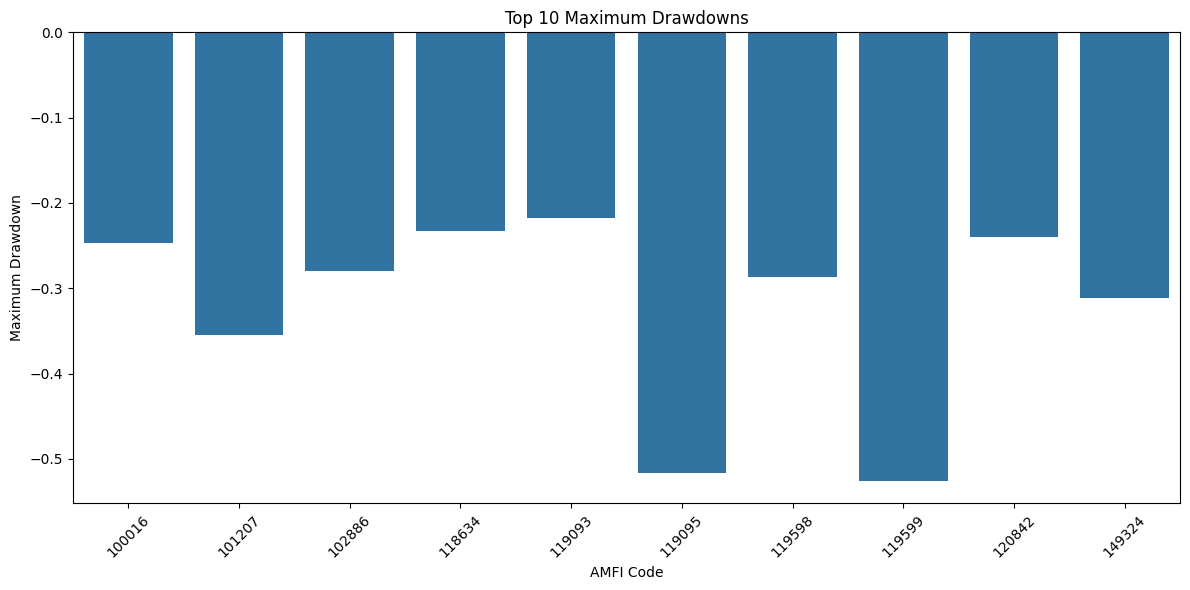

In [362]:
plt.figure(figsize=(12,6))

top_dd = drawdown_df.sort_values(
    "max_drawdown"
).head(10)

sns.barplot(
    data=top_dd,
    x="amfi_code",
    y="max_drawdown"
)

plt.title("Top 10 Maximum Drawdowns")
plt.xlabel("AMFI Code")
plt.ylabel("Maximum Drawdown")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [363]:
drawdown_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

print("max_drawdown.csv saved successfully!")

max_drawdown.csv saved successfully!


In [364]:
scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(
    ascending=False
)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(
    ascending=False
)

scorecard["alpha_rank"] = scorecard["alpha"].rank(
    ascending=False
)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True
)

scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(
    ascending=False
)

print(scorecard.head())

    amfi_code                                    scheme_name  return_3yr_pct  \
2      119598     SBI Small Cap Fund - Regular Plan - Growth           23.39   
22     120843         Kotak Flexicap Fund - Regular - Growth           15.65   
12     120505       ICICI Pru Midcap Fund - Regular - Growth           18.08   
34     148567  Mirae Asset Large Cap Fund - Regular - Growth           14.81   
11     120504      ICICI Pru Bluechip Fund - Direct - Growth           14.41   

    sharpe_ratio  expense_ratio_pct     alpha      beta  max_drawdown  \
2           0.94               1.43  0.301114  0.074266     -0.287060   
22          0.98               1.45  0.272784 -0.008737     -0.129740   
12          0.95               1.36  0.293014 -0.017391     -0.181885   
34          1.06               1.46  0.271150 -0.028133     -0.112657   
11          1.03               0.80  0.212094  0.017025     -0.125883   

    return_rank  sharpe_rank  alpha_rank  expense_rank  drawdown_rank   score  \

In [365]:
scorecard["score"] = (
    scorecard["return_rank"] * 0.30 +
    scorecard["sharpe_rank"] * 0.25 +
    scorecard["alpha_rank"] * 0.20 +
    scorecard["expense_rank"] * 0.15 +
    scorecard["drawdown_rank"] * 0.10
)

scorecard = scorecard.sort_values("score")

scorecard["final_rank"] = range(
    1,
    len(scorecard) + 1
)

print(
    scorecard[
        ["final_rank", "scheme_name", "score"]
    ].head(10)
)

    final_rank                                        scheme_name   score
2            1         SBI Small Cap Fund - Regular Plan - Growth  11.750
22           2             Kotak Flexicap Fund - Regular - Growth  11.900
12           3           ICICI Pru Midcap Fund - Regular - Growth  12.000
34           4      Mirae Asset Large Cap Fund - Regular - Growth  12.625
11           5          ICICI Pru Bluechip Fund - Direct - Growth  13.850
7            6  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  16.000
15           7     Nippon India Large Cap Fund - Regular - Growth  16.975
3            8          SBI Small Cap Fund - Direct Plan - Growth  17.500
13           9  ICICI Pru Value Discovery Fund - Regular - Growth  17.950
6           10           HDFC Top 100 Fund - Direct Plan - Growth  18.050


In [366]:
top5_codes = scorecard.sort_values("final_rank")["amfi_code"].head(5)

print(top5_codes)

2     119598
22    120843
12    120505
34    148567
11    120504
Name: amfi_code, dtype: int64


In [367]:
top5_nav = nav[
    nav["amfi_code"].isin(top5_codes)
].copy()

print(top5_nav.head())

      amfi_code       date      nav  daily_return
2300     119598 2022-01-03  89.8738           NaN
2301     119598 2022-01-04  88.5495     -0.014735
2302     119598 2022-01-05  88.0925     -0.005161
2303     119598 2022-01-06  88.5175      0.004824
2304     119598 2022-01-07  91.4235      0.032830


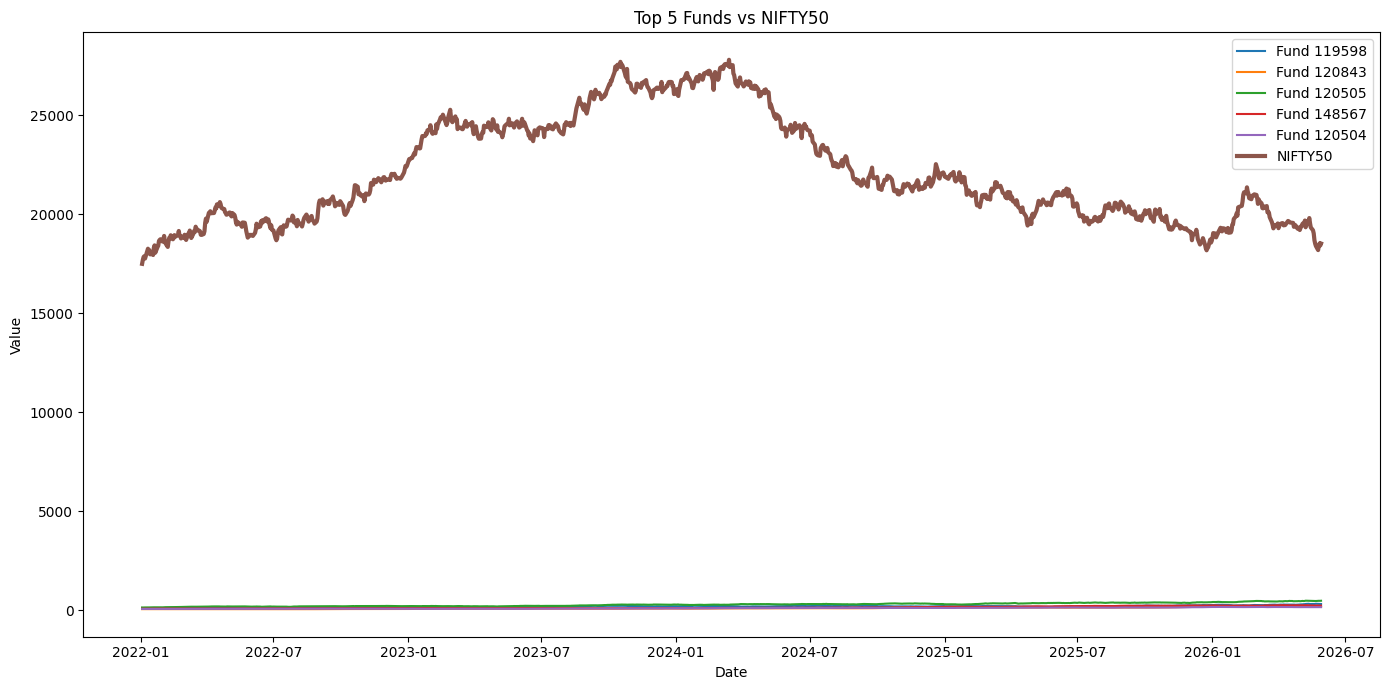

In [368]:
nifty["date"] = pd.to_datetime(nifty["date"])

plt.figure(figsize=(14,7))

# Plot Top 5 Funds
for code in top5_codes:
    temp = top5_nav[top5_nav["amfi_code"] == code]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=f"Fund {code}"
    )

# Plot NIFTY50
plt.plot(
    nifty["date"],
    nifty["close_value"],
    linewidth=3,
    label="NIFTY50"
)

plt.title("Top 5 Funds vs NIFTY50")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()

plt.show()

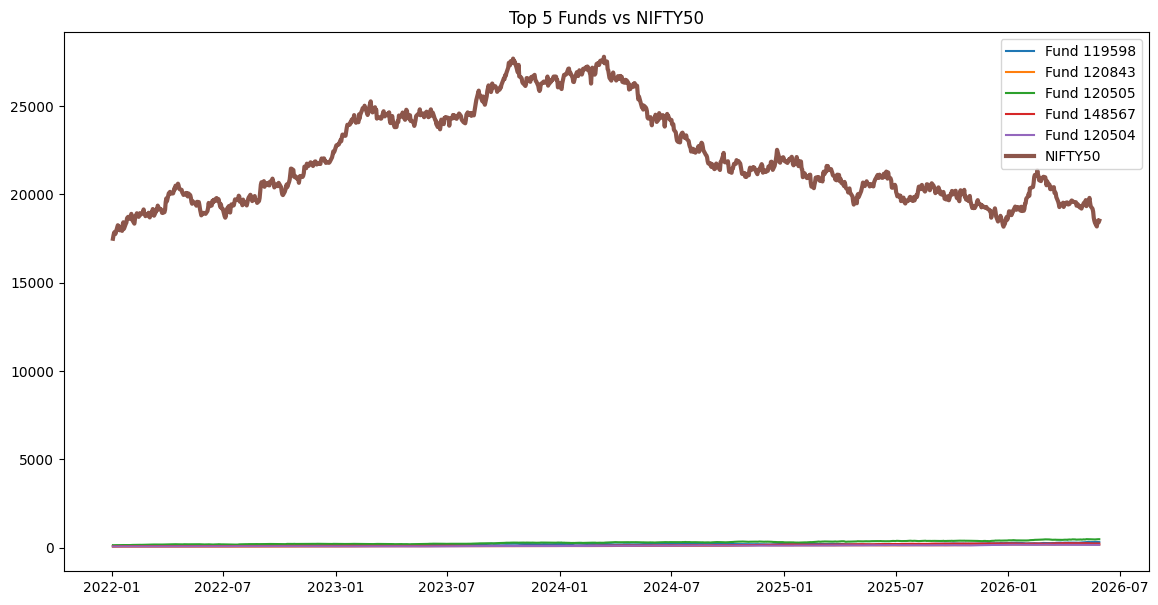

benchmark_comparison.png saved successfully!


In [369]:
plt.figure(figsize=(14,7))

for code in top5_codes:
    temp = top5_nav[top5_nav["amfi_code"] == code]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=f"Fund {code}"
    )

plt.plot(
    nifty["date"],
    nifty["close_value"],
    linewidth=3,
    label="NIFTY50"
)

plt.legend()
plt.title("Top 5 Funds vs NIFTY50")

plt.savefig(
    "../reports/benchmark_comparison.png"
)

plt.show()

print("benchmark_comparison.png saved successfully!")